# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Septa Bagas Setyawan
- Email: septabagas.2023@student.uny.ac.id
- Id Dicoding: CDCC015D6Y2100

## Persiapan

### Menyiapkan library yang dibutuhkan

In [1]:
import numpy as np
import pandas as pd

import scipy
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

import sqlalchemy
from sqlalchemy import create_engine

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

import joblib

from google.colab import files

pd.set_option('display.max_columns', None)

### Menyiapkan data yang akan diguankan

In [2]:
df = pd.read_csv('/content/employee_data.csv')

## Data Understanding

In [3]:
df.shape

(1470, 35)

In [4]:
df.head()

,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,38,NaN,Travel_Frequently,1444,Human Resources,1,4,Other,1,4,Male,88,3,1,Human Resources,2,Married,2991,5224,0,Y,Yes,11,3,2,80,1,7,2,3,6,2,1,2
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,1,Female,61,1,2,Healthcare Representative,2,Married,4777,14382,5,Y,No,15,3,1,80,0,15,2,1,1,0,0,0
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,1,Male,34,3,1,Research Scientist,3,Married,2461,10332,9,Y,Yes,12,3,3,80,3,18,2,4,10,0,2,7
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,3,Female,77,3,4,Sales Executive,2,Married,13525,14864,5,Y,No,14,3,4,80,1,23,2,4,20,4,4,8
4,5,40,NaN,Travel_Rarely,1194,Research & Development,2,4,Medical,1,3,Female,98,3,1,Research Scientist,3,Married,2001,12549,2,Y,No,14,3,2,80,3,20,2,3,5,3,0,2


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmployeeId                1470 non-null   int64  
 1   Age                       1470 non-null   int64  
 2   Attrition                 1058 non-null   float64
 3   BusinessTravel            1470 non-null   object 
 4   DailyRate                 1470 non-null   int64  
 5   Department                1470 non-null   object 
 6   DistanceFromHome          1470 non-null   int64  
 7   Education                 1470 non-null   int64  
 8   EducationField            1470 non-null   object 
 9   EmployeeCount             1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   object 
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1470 non-null   int64  
 14  JobLevel

In [6]:
df.isna().sum()

,0
EmployeeId,0
Age,0
Attrition,412
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0


In [7]:
df["Attrition"].isnull().sum()

np.int64(412)

In [8]:
print('Data Duplicated :', df.duplicated().sum())

Data Duplicated : 0


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
EmployeeId,1470.0,735.500000,424.496761,1.0,368.25,735.5,1102.75,1470.0
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
Attrition,1058.0,0.169187,0.375094,0.0,0.00,0.0,0.00,1.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0


## Data Preparation / Preprocessing

### Cleaning

In [10]:
df = df.dropna(subset=['Attrition'])

### Type Data

In [11]:
df['EmployeeId'] = df['EmployeeId'].astype(str)

### Labeling

In [12]:
Attrition_map = {
    0: 'No',
    1: 'Yes'
}

df['Attrition'] = df['Attrition'].map(Attrition_map)

In [13]:
Education_map = {
    1: 'Below College',
    2: 'College',
    3: 'Bachelor',
    4: 'Master',
    5: 'Doctor'
}

df['Education'] = df['Education'].map(Education_map)

In [14]:
EnvironmentSatisfaction_map ={
    1: 'Low',
    2: 'Medium',
    3: 'High',
    4: 'Very High'
}

df['EnvironmentSatisfaction'] = df['EnvironmentSatisfaction'].map(EnvironmentSatisfaction_map)

In [15]:
JobInvolvement_map = {
    1: 'Low',
    2: 'Medium',
    3: 'High',
    4: 'Very High'
}

df['JobInvolvement'] = df['JobInvolvement'].map(JobInvolvement_map)

In [16]:
JobSatisfaction_map = {
    1: 'Low',
    2: 'Medium',
    3: 'High',
    4: 'Very High'
}

df['JobSatisfaction'] = df['JobSatisfaction'].map(JobSatisfaction_map)

In [17]:
PerformanceRating = {
    1: 'Low',
    2: 'Good',
    3: 'Excellent',
    4: 'Outstanding'
}

df['PerformanceRating'] = df['PerformanceRating'].map(PerformanceRating)

In [18]:
RelationshipSatisfaction = {
    1: 'Low',
    2: 'Medium',
    3: 'High',
    4: 'Very High'
}

df['RelationshipSatisfaction'] = df['RelationshipSatisfaction'].map(RelationshipSatisfaction)

In [19]:
WorkLifeBalance = {
    1: 'Low',
    2: 'Good',
    3: 'Excellent',
    4: 'Outstanding'
}

df['WorkLifeBalance'] = df['WorkLifeBalance'].map(WorkLifeBalance)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1058 entries, 1 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   EmployeeId                1058 non-null   object
 1   Age                       1058 non-null   int64 
 2   Attrition                 1058 non-null   object
 3   BusinessTravel            1058 non-null   object
 4   DailyRate                 1058 non-null   int64 
 5   Department                1058 non-null   object
 6   DistanceFromHome          1058 non-null   int64 
 7   Education                 1058 non-null   object
 8   EducationField            1058 non-null   object
 9   EmployeeCount             1058 non-null   int64 
 10  EnvironmentSatisfaction   1058 non-null   object
 11  Gender                    1058 non-null   object
 12  HourlyRate                1058 non-null   int64 
 13  JobInvolvement            1058 non-null   object
 14  JobLevel                  105

In [21]:
df.head()

,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1,2,37,Yes,Travel_Rarely,1141,Research & Development,11,College,Medical,1,Low,Female,61,Low,2,Healthcare Representative,Medium,Married,4777,14382,5,Y,No,15,Excellent,Low,80,0,15,2,Low,1,0,0,0
2,3,51,Yes,Travel_Rarely,1323,Research & Development,4,Master,Life Sciences,1,Low,Male,34,High,1,Research Scientist,High,Married,2461,10332,9,Y,Yes,12,Excellent,High,80,3,18,2,Outstanding,10,0,2,7
3,4,42,No,Travel_Frequently,555,Sales,26,Bachelor,Marketing,1,High,Female,77,High,4,Sales Executive,Medium,Married,13525,14864,5,Y,No,14,Excellent,Very High,80,1,23,2,Outstanding,20,4,4,8
6,7,40,No,Travel_Rarely,1124,Sales,1,College,Medical,1,Medium,Male,57,Low,2,Sales Executive,Very High,Married,7457,13273,2,Y,Yes,22,Outstanding,High,80,3,6,2,Good,4,3,0,2
7,8,55,Yes,Travel_Rarely,725,Research & Development,2,Bachelor,Medical,1,Very High,Male,78,High,5,Manager,Low,Married,19859,21199,5,Y,Yes,13,Excellent,Very High,80,1,24,2,Excellent,5,2,1,4


## Exploratory Data Analyst (EDA)

### Berapa banyak karyawan yang keluar?

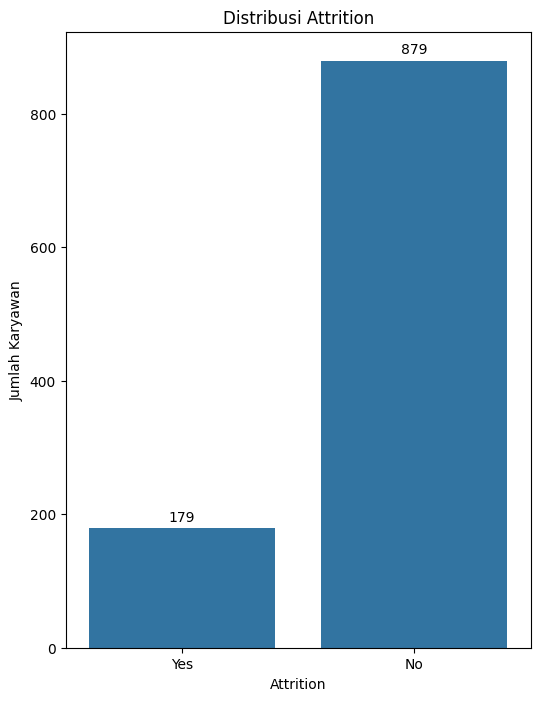

In [22]:
plt.figure(figsize=(6,8))

ax = sns.countplot(
    data=df,
    x='Attrition',
)

for container in ax.containers:
  ax.bar_label(container, fmt='%d', padding=3)

plt.title("Distribusi Attrition")
plt.xlabel("Attrition")
plt.ylabel("Jumlah Karyawan")

plt.show()

### Department mana yang paling banyak mengalami attrition?

In [23]:
depart_rate = (
    df.groupby('Department')['Attrition']
    .value_counts(normalize=True)
    .rename('Rate')
    .mul(100)
    .reset_index()
    .sort_values(by='Rate', ascending=False)
)

depart_rate

,Department,Attrition,Rate
2,Research & Development,No,84.736091
0,Human Resources,No,84.210526
4,Sales,No,79.310345
5,Sales,Yes,20.689655
1,Human Resources,Yes,15.789474
3,Research & Development,Yes,15.263909


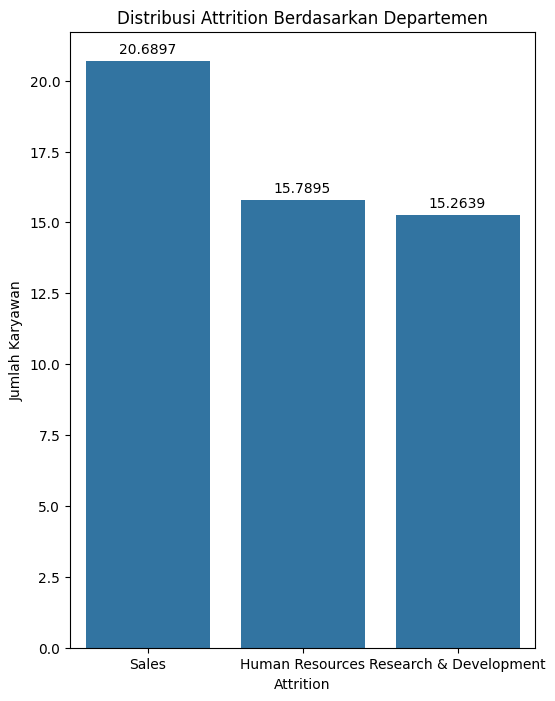

In [24]:
plt.figure(figsize=(6,8))

ax = sns.barplot(
    data=depart_rate[depart_rate["Attrition"]=="Yes"],
    x='Department',
    y='Rate'
)

for container in ax.containers:
    ax.bar_label(container,padding=3)

plt.title("Distribusi Attrition Berdasarkan Departemen")
plt.xlabel("Attrition")
plt.ylabel("Jumlah Karyawan")

plt.show()

### Apakah OverTime berhubungan dengan attrition?

In [25]:
overtime_rate = (
    df.groupby('OverTime')['Attrition']
    .value_counts(normalize=True)
    .rename('Rate')
    .mul(100)
    .reset_index()
    .sort_values(by='Rate', ascending=False)
)

overtime_rate

,OverTime,Attrition,Rate
0,No,No,89.214381
2,Yes,No,68.078176
3,Yes,Yes,31.921824
1,No,Yes,10.785619


/tmp/ipykernel_2177/2180653317.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Attrition")


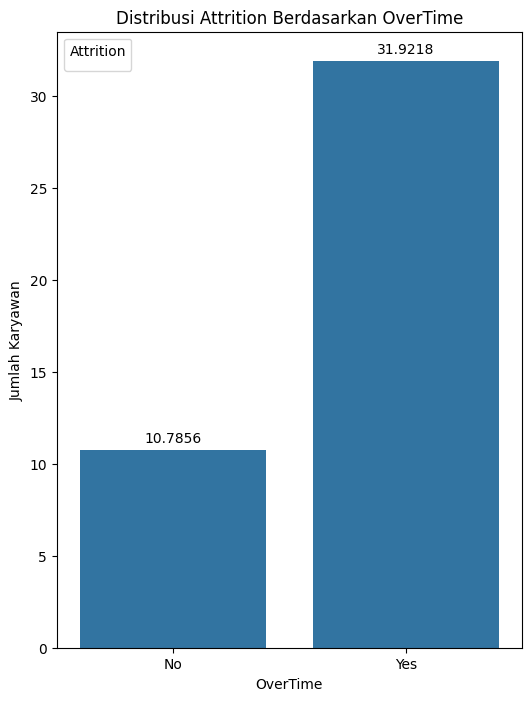

In [26]:
plt.figure(figsize=(6,8))

ax = sns.barplot(
    data=overtime_rate[overtime_rate['Attrition']=='Yes'],
    x='OverTime',
    y='Rate',
    order=["No", "Yes"],
)

for container in ax.containers:
  ax.bar_label(container,padding=3)

plt.title("Distribusi Attrition Berdasarkan OverTime")
plt.xlabel("OverTime")
plt.ylabel("Jumlah Karyawan")
plt.legend(title="Attrition")

plt.show()

### Apakah Job Satisfaction berhubungan dengan attrition?

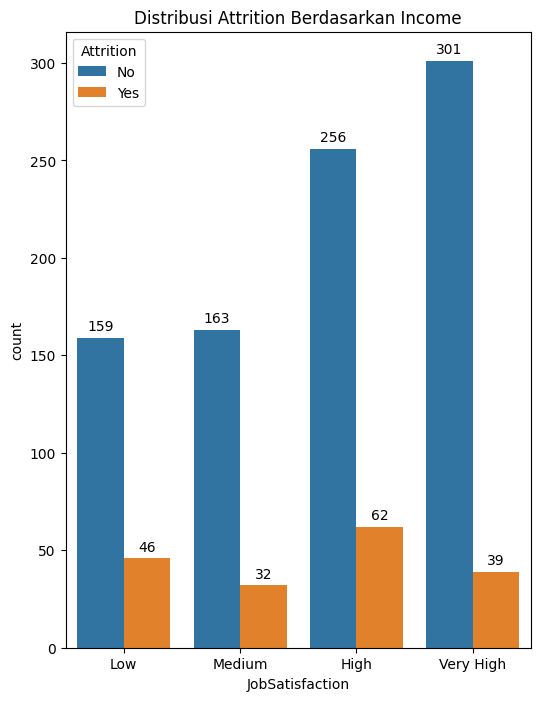

In [27]:
plt.figure(figsize=(6,8))

ax = sns.countplot(
    data=df,
    x='JobSatisfaction',
    hue='Attrition',
    order=['Low','Medium','High','Very High'],
    hue_order=['No','Yes']
)

for container in ax.containers:
  ax.bar_label(container,fmt='%d',padding=3)

plt.title("Distribusi Attrition Berdasarkan Income")

plt.show()

### Apakah karyawan baru lebih sering keluar?

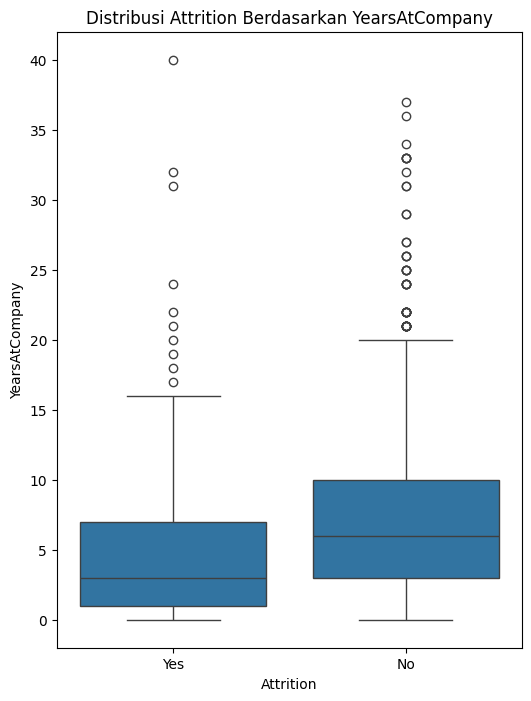

In [28]:
plt.figure(figsize=(6,8))

sns.boxplot(
    data=df,
    x="Attrition",
    y="YearsAtCompany"
)

plt.title("Distribusi Attrition Berdasarkan YearsAtCompany")
plt.show()

### Apakah pendapatan berpengaruh?

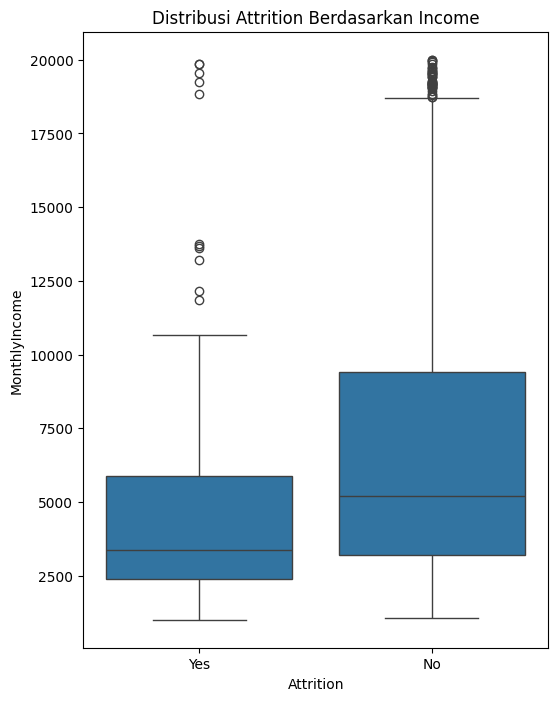

In [29]:
plt.figure(figsize=(6,8))

sns.boxplot(
    data=df,
    x='Attrition',
    y='MonthlyIncome'
)

plt.title("Distribusi Attrition Berdasarkan Income")
plt.show()

### Apakah usia berpengaruh?

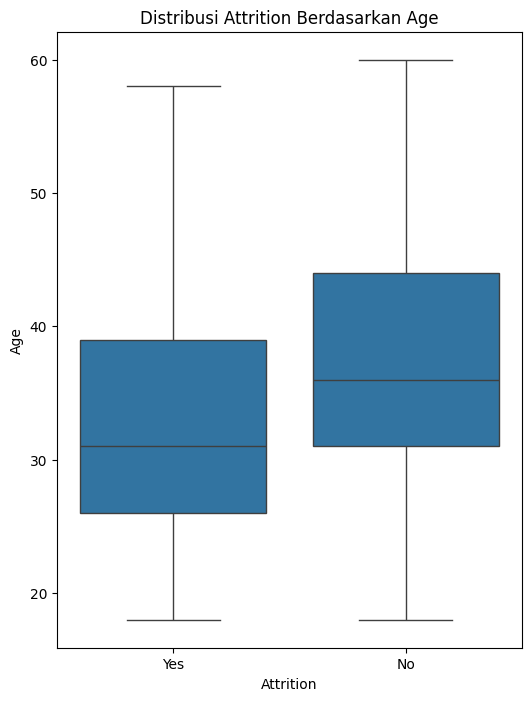

In [30]:
plt.figure(figsize=(6,8))

sns.boxplot(
    data=df,
    x='Attrition',
    y='Age'
)

plt.title("Distribusi Attrition Berdasarkan Age")
plt.show()

### Apakah Work-Life Balance berpengaruh?

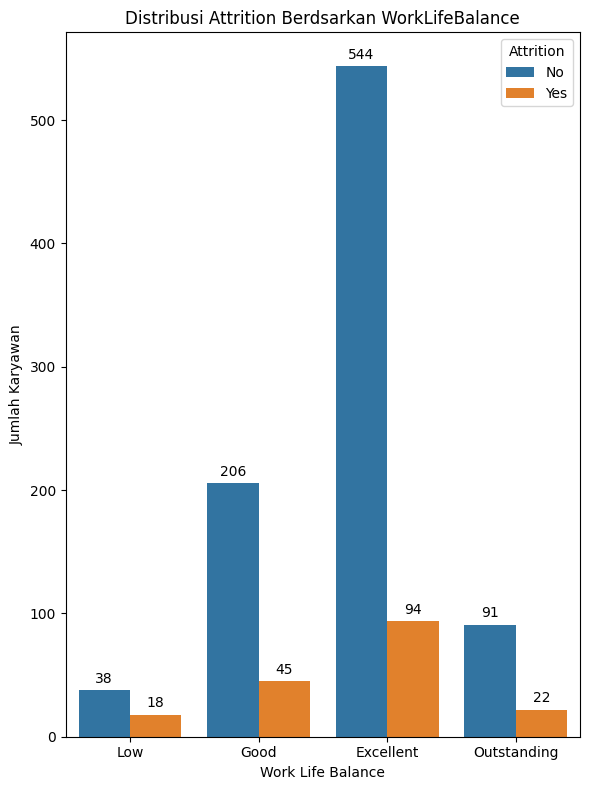

In [31]:
plt.figure(figsize=(6,8))

ax = sns.countplot(
    data=df,
    x='WorkLifeBalance',
    hue='Attrition',
    order=['Low', 'Good', 'Excellent', 'Outstanding'],
    hue_order=['No','Yes']
)

for container in ax.containers:
  ax.bar_label(container, fmt='%d', padding=3)

plt.title("Distribusi Attrition Berdsarkan WorkLifeBalance")
plt.xlabel("Work Life Balance")
plt.ylabel("Jumlah Karyawan")
plt.legend(title='Attrition')

plt.tight_layout()
plt.show()

### Hubungan antar variabel numerik

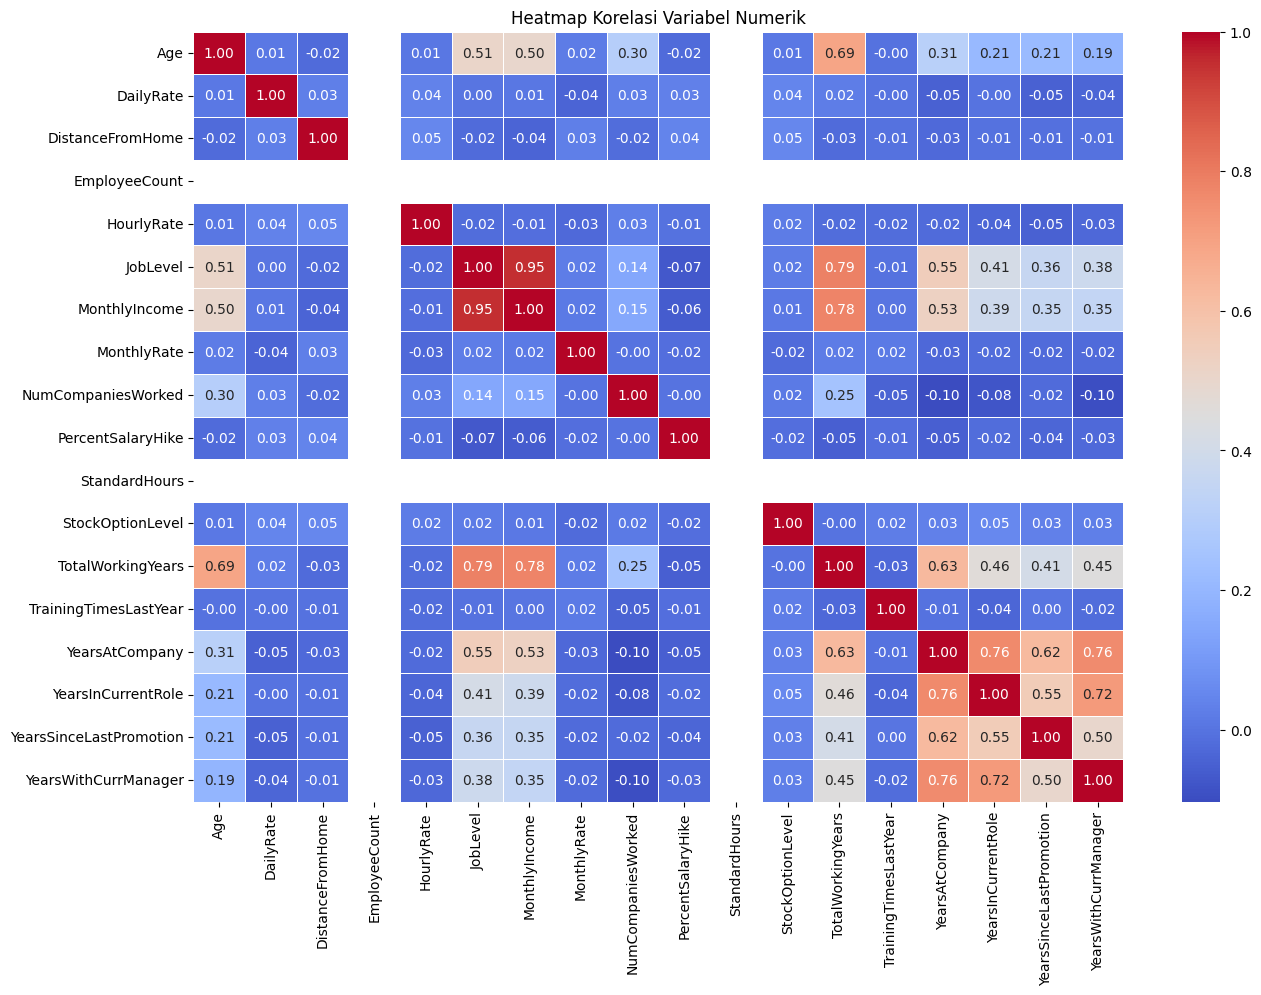

In [32]:
plt.figure(figsize=(15,10))

corr = df.select_dtypes(include=["int64", "float64"]).corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Heatmap Korelasi Variabel Numerik")
plt.show()

## Conclusion

1. Berapa Banyak Karyawan yang Keluar?

    Berdasarkann hasil analisis yang telah dilakukan, terdapat 179 karyawan yang Attrition dan 879 karyawan lainnya masih bertahan


2. Faktor Yang Mempengaruhinya hal tersebut:

    Berdasarkan hasil EDA ditemukan beberapa karakteristik yang sering muncul pada karyawan yang keluar

    a. karyawan yang lembur (OverTime) memiliki jumlah Attrition yang tinggi dibandingkan yang tidak lembur
    
    b. Karyawan yang masa kerjanya pendek / pekerja baru lebih sering keluar

    c. Karyawan yang keluar cenderung memiliki pendapatan yang rendah

    d. karyawan yang keluar cenderung memiliki usia yang masih muda

    e. Tingkat Job Satisfaction dan Work Life Balence yang lebih rendah menunjukkan jumlah Attrition yang lebih tinggi

## Simpan Hasil

In [34]:
df.to_csv("employee_data_clean.csv", index=False)

print("File berhasil dibuat!")
print("Jumlah baris:", df.shape[0])
print("Jumlah kolom:", df.shape[1])

File berhasil dibuat!
Jumlah baris: 1058
Jumlah kolom: 35
